In [1]:
import subprocess
result = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
print(result.stdout)


import torch
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Thu Jun  4 15:51:29 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.105.08             Driver Version: 580.105.08     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   41C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
from pathlib import Path
import os

# Kaggle working directory — persists for the session
BASE_DIR = Path("/kaggle/working/finance-finetune")

dirs = [
    BASE_DIR / "data",
    BASE_DIR / "outputs" / "phi3-finance-lora",
    BASE_DIR / "results",
]
for d in dirs:
    d.mkdir(parents=True, exist_ok=True)

print(f"Project directory: {BASE_DIR}")
print("Directories created:")
for d in dirs:
    print(f"  {d}")

Project directory: /kaggle/working/finance-finetune
Directories created:
  /kaggle/working/finance-finetune/data
  /kaggle/working/finance-finetune/outputs/phi3-finance-lora
  /kaggle/working/finance-finetune/results


In [3]:
import subprocess
import sys

def install(package):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package])

def check_and_install(package, import_name=None):
    import_name = import_name or package.split("==")[0].split(">=")[0]
    try:
        __import__(import_name)
        print(f"✅ {package} already installed")
    except ImportError:
        print(f"📦 Installing {package}...")
        install(package)
        print(f"✅ {package} installed")

# Check each package individually
check_and_install("transformers", "transformers")
check_and_install("datasets", "datasets")
check_and_install("peft", "peft")
check_and_install("trl", "trl")
check_and_install("bitsandbytes", "bitsandbytes")
check_and_install("accelerate", "accelerate")
check_and_install("sentencepiece", "sentencepiece")
check_and_install("rouge-score", "rouge_score")
check_and_install("openai", "openai")
check_and_install("gradio", "gradio")

# Print final versions of critical packages
import transformers, peft, trl, bitsandbytes
print(f"\n{'='*40}")
print(f"transformers: {transformers.__version__}")
print(f"peft:         {peft.__version__}")
print(f"trl:          {trl.__version__}")
print(f"bitsandbytes: {bitsandbytes.__version__}")
print(f"{'='*40}")
print("✅ All packages ready")

✅ transformers already installed
✅ datasets already installed
✅ peft already installed
📦 Installing trl...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 761.1/761.1 kB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 95.0 MB/s eta 0:00:00


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cudf-cu12 26.2.1 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cudf-cu12 26.2.1 requires numba-cuda[cu12]<0.23.0,>=0.22.2, but you hav

✅ trl installed
📦 Installing bitsandbytes...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 32.4 MB/s eta 0:00:00
✅ bitsandbytes installed
✅ accelerate already installed
✅ sentencepiece already installed
✅ rouge-score already installed
✅ openai already installed
✅ gradio already installed

transformers: 5.0.0
peft:         0.18.1
trl:          1.5.1
bitsandbytes: 0.49.2
✅ All packages ready


In [4]:
from kaggle_secrets import UserSecretsClient
from huggingface_hub import login

secrets = UserSecretsClient()

try:
    hf_token = secrets.get_secret("HF_TOKEN")
    login(token=hf_token)
    print("✅ Logged in via Kaggle Secrets")
except Exception as e:
    print(f"HF login skipped: {e}")
    print("Phi-3 does not require login — continuing")
    hf_token = None

✅ Logged in via Kaggle Secrets


In [5]:
from kaggle_secrets import UserSecretsClient

secrets = UserSecretsClient()

try:
    AZURE_KEY = secrets.get_secret("AZURE_OPENAI_KEY")
    AZURE_ENDPOINT = secrets.get_secret("AZURE_OPENAI_ENDPOINT")
    AZURE_DEPLOYMENT = secrets.get_secret("AZURE_OPENAI_DEPLOYMENT")
    AZURE_API_VERSION = secrets.get_secret("AZURE_OPENAI_API_VERSION")
    print("✅ Azure credentials loaded from Kaggle Secrets")
except Exception as e:
    print(f"❌ Could not load Azure credentials: {e}")
    print("Add them via Add-ons → Secrets in the Kaggle toolbar")
    AZURE_KEY = None
    AZURE_ENDPOINT = None
    AZURE_DEPLOYMENT = "gpt-5"
    AZURE_API_VERSION = "2024-02-15-preview"

✅ Azure credentials loaded from Kaggle Secrets


In [6]:
from datasets import load_dataset, load_from_disk
import json
from pathlib import Path

DATA_TRAIN = BASE_DIR / "data" / "train"
DATA_VAL = BASE_DIR / "data" / "val"
EVAL_SAMPLES_PATH = BASE_DIR / "data" / "eval_samples.json"

# Kaggle working dir does NOT persist between sessions
# so we always re-download — it only takes ~1 minute
print("Downloading dataset...")
dataset = load_dataset("gbharti/finance-alpaca")
print(f"Total samples: {len(dataset['train'])}")

def format_prompt(example):
    input_part = (
        f"\n\n### Input:\n{example['input']}"
        if example['input'] and example['input'].strip()
        else ""
    )
    return {
        "text": f"### Instruction:\n{example['instruction']}"
                f"{input_part}\n\n### Response:\n{example['output']}"
    }

formatted = dataset["train"].map(format_prompt)
train_data = formatted.select(range(5000))
val_data = formatted.select(range(5000, 5500))

train_data.save_to_disk(str(DATA_TRAIN))
val_data.save_to_disk(str(DATA_VAL))

eval_samples = [val_data[i] for i in range(20)]
with open(EVAL_SAMPLES_PATH, "w") as f:
    json.dump(eval_samples, f, indent=2)

print(f"✅ Train: {len(train_data)} samples")
print(f"✅ Val:   {len(val_data)} samples")
print(f"✅ Eval:  20 samples saved to {EVAL_SAMPLES_PATH}")
print("\nSample formatted prompt:")
print(train_data[0]["text"][:400])

README.md:   0%|          | 0.00/831 [00:00<?, ?B/s]

Cleaned_date.json:   0%|          | 0.00/42.9M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/68912 [00:00<?, ? examples/s]

Total samples: 68912


Map:   0%|          | 0/68912 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/5000 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/500 [00:00<?, ? examples/s]

✅ Train: 5000 samples
✅ Val:   500 samples
✅ Eval:  20 samples saved to /kaggle/working/finance-finetune/data/eval_samples.json

Sample formatted prompt:
### Instruction:
For a car, what scams can be plotted with 0% financing vs rebate?

### Response:
The car deal makes money 3 ways. If you pay in one lump payment. If the payment is greater than what they paid for the car, plus their expenses, they make a profit. They loan you the money. You make payments over months or years, if the total amount you pay is greater than what they paid for the car, 


In [7]:
import torch
import json
import time
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from rouge_score import rouge_scorer
import transformers

print(f"Transformers version: {transformers.__version__}")

# ── Config ────────────────────────────────────────────────────────
MODEL_NAME = "microsoft/Phi-3-mini-4k-instruct"
BASELINE_RESULTS_PATH = BASE_DIR / "results" / "baseline_results.json"
BASELINE_RESULTS_PATH.parent.mkdir(parents=True, exist_ok=True)

if BASELINE_RESULTS_PATH.exists():
    print(f"Baseline results already exist at {BASELINE_RESULTS_PATH}")
else:
    print(f"Loading {MODEL_NAME}...")

    bnb_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_use_double_quant=True,
        bnb_4bit_quant_type="nf4",
        bnb_4bit_compute_dtype=torch.bfloat16
    )

    tokenizer = AutoTokenizer.from_pretrained(
        MODEL_NAME,
        trust_remote_code=False,    # ← use built-in transformers code
    )

    base_model = AutoModelForCausalLM.from_pretrained(
        MODEL_NAME,
        quantization_config=bnb_config,
        device_map="auto",
        trust_remote_code=False,    # ← use built-in transformers code
        attn_implementation="eager"
    )
    print("✅ Model loaded")

    scorer = rouge_scorer.RougeScorer(
        ['rouge1', 'rougeL'], use_stemmer=True
    )

    with open(EVAL_SAMPLES_PATH) as f:
        eval_samples = json.load(f)

    results = []
    for i, sample in enumerate(eval_samples):
        text = sample["text"]
        instruction = text.split("### Response:")[0].strip()
        reference = text.split("### Response:")[1].strip()

        prompt = f"{instruction}\n\n### Response:\n"
        inputs = tokenizer(
            prompt,
            return_tensors="pt",
            truncation=True,
            max_length=512
        ).to("cuda")

        start = time.time()
        with torch.no_grad():
            outputs = base_model.generate(
                **inputs,
                max_new_tokens=150,
                temperature=0.1,
                do_sample=True,
                pad_token_id=tokenizer.eos_token_id
            )
        latency = round(time.time() - start, 2)

        response = tokenizer.decode(outputs[0], skip_special_tokens=True)
        generated = response.split("### Response:")[-1].strip()

        scores = scorer.score(reference, generated)
        rouge1 = round(scores['rouge1'].fmeasure, 3)
        rougeL = round(scores['rougeL'].fmeasure, 3)

        results.append({
            "sample_id": i,
            "instruction": instruction[:200],
            "reference": reference[:200],
            "generated": generated[:200],
            "rouge1": rouge1,
            "rougeL": rougeL,
            "latency_seconds": latency
        })
        print(f"Sample {i+1}/20 — ROUGE-L: {rougeL:.3f} ({latency}s)")

    avg_r1 = round(sum(r["rouge1"] for r in results) / len(results), 3)
    avg_rL = round(sum(r["rougeL"] for r in results) / len(results), 3)
    avg_lat = round(sum(r["latency_seconds"] for r in results) / len(results), 1)

    print(f"\n{'='*45}")
    print(f"Baseline ({MODEL_NAME})")
    print(f"{'='*45}")
    print(f"Avg ROUGE-1:  {avg_r1}")
    print(f"Avg ROUGE-L:  {avg_rL}")
    print(f"Avg Latency:  {avg_lat}s")
    print(f"{'='*45}")

    with open(BASELINE_RESULTS_PATH, "w") as f:
        json.dump(results, f, indent=2)
    print(f"\n✅ Saved to {BASELINE_RESULTS_PATH}")

    del base_model
    torch.cuda.empty_cache()
    print("Model unloaded from VRAM")

Transformers version: 5.0.0
Loading microsoft/Phi-3-mini-4k-instruct...


config.json:   0%|          | 0.00/967 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/195 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/181 [00:00<?, ?B/s]

✅ Model loaded
Sample 1/20 — ROUGE-L: 0.083 (13.71s)
Sample 2/20 — ROUGE-L: 0.146 (11.88s)
Sample 3/20 — ROUGE-L: 0.142 (12.08s)
Sample 4/20 — ROUGE-L: 0.063 (11.52s)
Sample 5/20 — ROUGE-L: 0.140 (11.1s)
Sample 6/20 — ROUGE-L: 0.210 (11.21s)
Sample 7/20 — ROUGE-L: 0.188 (11.2s)
Sample 8/20 — ROUGE-L: 0.074 (11.21s)
Sample 9/20 — ROUGE-L: 0.184 (11.22s)
Sample 10/20 — ROUGE-L: 0.131 (11.14s)
Sample 11/20 — ROUGE-L: 0.082 (11.1s)
Sample 12/20 — ROUGE-L: 0.115 (11.13s)
Sample 13/20 — ROUGE-L: 0.159 (11.09s)
Sample 14/20 — ROUGE-L: 0.087 (11.15s)
Sample 15/20 — ROUGE-L: 0.155 (11.2s)
Sample 16/20 — ROUGE-L: 0.131 (11.31s)
Sample 17/20 — ROUGE-L: 0.149 (11.23s)
Sample 18/20 — ROUGE-L: 0.114 (11.22s)
Sample 19/20 — ROUGE-L: 0.132 (11.19s)
Sample 20/20 — ROUGE-L: 0.138 (11.3s)

Baseline (microsoft/Phi-3-mini-4k-instruct)
Avg ROUGE-1:  0.238
Avg ROUGE-L:  0.131
Avg Latency:  11.4s

✅ Saved to /kaggle/working/finance-finetune/results/baseline_results.json
Model unloaded from VRAM


In [8]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from peft import LoraConfig
from trl import SFTTrainer, SFTConfig
from datasets import load_from_disk
import transformers, trl

print(f"Transformers version: {transformers.__version__}")
print(f"TRL version: {trl.__version__}")

# ── Config ────────────────────────────────────────────────────────
MODEL_NAME = "microsoft/Phi-3-mini-4k-instruct"
ADAPTER_PATH = BASE_DIR / "outputs" / "phi3-finance-lora"
ADAPTER_PATH.mkdir(parents=True, exist_ok=True)

if (ADAPTER_PATH / "adapter_config.json").exists():
    print(f"✅ Fine-tuned adapter already exists at {ADAPTER_PATH}")
    print("Skipping training — delete the folder to retrain")
else:
    print(f"Loading {MODEL_NAME} for fine-tuning...")

    bnb_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_use_double_quant=True,
        bnb_4bit_quant_type="nf4",
        bnb_4bit_compute_dtype=torch.bfloat16
    )

    tokenizer = AutoTokenizer.from_pretrained(
        MODEL_NAME,
        trust_remote_code=False,
    )
    tokenizer.pad_token = tokenizer.eos_token
    tokenizer.padding_side = "right"

    model = AutoModelForCausalLM.from_pretrained(
        MODEL_NAME,
        quantization_config=bnb_config,
        device_map="auto",
        trust_remote_code=False,
        attn_implementation="eager"
    )
    model.config.use_cache = False
    print("✅ Model loaded")

    lora_config = LoraConfig(
        r=16,
        lora_alpha=32,
        target_modules=["q_proj", "k_proj", "v_proj", "o_proj"],
        lora_dropout=0.05,
        bias="none",
        task_type="CAUSAL_LM"
    )

    print("Loading datasets...")
    train_data = load_from_disk(str(DATA_TRAIN))
    val_data = load_from_disk(str(DATA_VAL))
    print(f"Train: {len(train_data)} | Val: {len(val_data)}")

    sft_config = SFTConfig(
        # ── output ──────────────────────────────
        output_dir=str(ADAPTER_PATH),
        # ── steps / epochs ──────────────────────
        max_steps=500,
        # ── batch / accumulation ────────────────
        per_device_train_batch_size=4,
        gradient_accumulation_steps=4,
        # ── learning rate ───────────────────────
        learning_rate=2e-4,
        lr_scheduler_type="cosine",
        warmup_ratio=0.05,
        # ── precision ───────────────────────────
        fp16=False,
        bf16=True,
        # ── memory ──────────────────────────────
        gradient_checkpointing=True,
        optim="paged_adamw_8bit",
        max_grad_norm=0.3,
        # ── logging ─────────────────────────────
        logging_steps=10,
        report_to="none",
        # ── saving ──────────────────────────────
        save_strategy="steps",
        save_steps=100,
        save_total_limit=2,
        # ── eval ────────────────────────────────
        eval_strategy="steps",
        eval_steps=100,
        # ── data / sequence ─────────────────────
        dataset_text_field="text",  # back in SFTConfig in TRL 1.5.1
        max_length=512,             # replaces max_seq_length
        packing=False,
    )

    trainer = SFTTrainer(
        model=model,
        train_dataset=train_data,
        eval_dataset=val_data,
        peft_config=lora_config,
        processing_class=tokenizer,
        args=sft_config,
    )

    print("\n" + "="*50)
    print("Training started")
    print("Expected time: ~45–60 minutes on T4")
    print("Checkpoints saved to Google Drive every 100 steps")
    print("="*50 + "\n")

    trainer.train()

    model.save_pretrained(str(ADAPTER_PATH))
    tokenizer.save_pretrained(str(ADAPTER_PATH))
    print(f"\n✅ Adapter saved to {ADAPTER_PATH}")

    del model
    torch.cuda.empty_cache()
    print("Model unloaded from VRAM")

Transformers version: 5.0.0
TRL version: 1.5.1
Loading microsoft/Phi-3-mini-4k-instruct for fine-tuning...


Loading weights:   0%|          | 0/195 [00:00<?, ?it/s]

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


✅ Model loaded
Loading datasets...
Train: 5000 | Val: 500


Adding EOS to train dataset:   0%|          | 0/5000 [00:00<?, ? examples/s]

...

Tokenizing eval dataset:   0%|          | 0/500 [00:00<?, ? examples/s]


Training started
Expected time: ~45–60 minutes on T4
Checkpoints saved to Google Drive every 100 steps



Step,Training Loss,Validation Loss,Entropy,Num Tokens,Mean Token Accuracy
100,2.184446,2.162343,2.172243,415562.000000,0.512535
200,2.137681,2.153747,2.159264,818943.000000,0.514036
300,2.138046,2.150362,2.162302,1218864.000000,0.514785
400,2.119943,2.148888,2.151891,1623248.000000,0.515183
500,2.143372,2.148627,2.156187,2027252.000000,0.515519


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


✅ Adapter saved to /kaggle/working/finance-finetune/outputs/phi3-finance-lora
Model unloaded from VRAM


In [13]:
# The adapter is in checkpoint-500, not the root folder
# Update ADAPTER_PATH to point to the correct location
ADAPTER_PATH_FINAL = ADAPTER_PATH / "checkpoint-500"
print(f"Using adapter from: {ADAPTER_PATH_FINAL}")
print(f"adapter_config.json exists: {(ADAPTER_PATH_FINAL / 'adapter_config.json').exists()}")
print(f"adapter_model.safetensors exists: {(ADAPTER_PATH_FINAL / 'adapter_model.safetensors').exists()}")

Using adapter from: /kaggle/working/finance-finetune/outputs/phi3-finance-lora/checkpoint-500
adapter_config.json exists: True
adapter_model.safetensors exists: True


In [14]:
import torch
import json
import time
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from peft import PeftModel
from rouge_score import rouge_scorer
import transformers

print(f"Transformers version: {transformers.__version__}")

# ── Config ────────────────────────────────────────────────────────
MODEL_NAME = "microsoft/Phi-3-mini-4k-instruct"

# Use checkpoint-500 where adapter_config.json actually exists
ADAPTER_PATH_FINAL = ADAPTER_PATH / "checkpoint-500"
FINETUNED_RESULTS_PATH = BASE_DIR / "results" / "finetuned_results.json"
FINETUNED_RESULTS_PATH.parent.mkdir(parents=True, exist_ok=True)

if FINETUNED_RESULTS_PATH.exists():
    print(f"Fine-tuned results already exist at {FINETUNED_RESULTS_PATH}")
    print("Delete the file and re-run if you want to redo this eval")
else:
    if not (ADAPTER_PATH_FINAL / "adapter_config.json").exists():
        print("❌ No fine-tuned adapter found.")
        print(f"   Expected at: {ADAPTER_PATH_FINAL}")
        print(f"   Contents of parent: {list(ADAPTER_PATH.iterdir())}")
    else:
        print(f"✅ Adapter found at: {ADAPTER_PATH_FINAL}")
        print(f"Loading fine-tuned model...")

        bnb_config = BitsAndBytesConfig(
            load_in_4bit=True,
            bnb_4bit_use_double_quant=True,
            bnb_4bit_quant_type="nf4",
            bnb_4bit_compute_dtype=torch.bfloat16
        )

        # Load tokenizer from checkpoint (has the correct config)
        tokenizer = AutoTokenizer.from_pretrained(
            str(ADAPTER_PATH_FINAL),
            trust_remote_code=False,
        )

        # Load base model
        base = AutoModelForCausalLM.from_pretrained(
            MODEL_NAME,
            quantization_config=bnb_config,
            device_map="auto",
            trust_remote_code=False,
            attn_implementation="eager"
        )

        # Load LoRA adapter on top of base model
        model = PeftModel.from_pretrained(
            base,
            str(ADAPTER_PATH_FINAL)  # point to checkpoint-500
        )
        print("✅ Fine-tuned model loaded")

        scorer = rouge_scorer.RougeScorer(
            ['rouge1', 'rougeL'], use_stemmer=True
        )

        with open(EVAL_SAMPLES_PATH) as f:
            eval_samples = json.load(f)

        results = []
        for i, sample in enumerate(eval_samples):
            text = sample["text"]
            instruction = text.split("### Response:")[0].strip()
            reference = text.split("### Response:")[1].strip()

            prompt = f"{instruction}\n\n### Response:\n"
            inputs = tokenizer(
                prompt,
                return_tensors="pt",
                truncation=True,
                max_length=512
            ).to("cuda")

            start = time.time()
            with torch.no_grad():
                outputs = model.generate(
                    **inputs,
                    max_new_tokens=150,
                    temperature=0.1,
                    do_sample=True,
                    pad_token_id=tokenizer.eos_token_id
                )
            latency = round(time.time() - start, 2)

            response = tokenizer.decode(outputs[0], skip_special_tokens=True)
            generated = response.split("### Response:")[-1].strip()

            scores = scorer.score(reference, generated)
            rouge1 = round(scores['rouge1'].fmeasure, 3)
            rougeL = round(scores['rougeL'].fmeasure, 3)

            results.append({
                "sample_id": i,
                "instruction": instruction[:200],
                "reference": reference[:200],
                "generated": generated[:200],
                "rouge1": rouge1,
                "rougeL": rougeL,
                "latency_seconds": latency
            })
            print(f"Sample {i+1}/20 — ROUGE-L: {rougeL:.3f} ({latency}s)")

        avg_r1 = round(sum(r["rouge1"] for r in results) / len(results), 3)
        avg_rL = round(sum(r["rougeL"] for r in results) / len(results), 3)
        avg_lat = round(sum(r["latency_seconds"] for r in results) / len(results), 1)

        print(f"\n{'='*45}")
        print(f"Fine-tuned (Phi-3 Mini + LoRA checkpoint-500)")
        print(f"{'='*45}")
        print(f"Avg ROUGE-1:  {avg_r1}")
        print(f"Avg ROUGE-L:  {avg_rL}")
        print(f"Avg Latency:  {avg_lat}s")
        print(f"{'='*45}")

        with open(FINETUNED_RESULTS_PATH, "w") as f:
            json.dump(results, f, indent=2)
        print(f"\n✅ Saved to {FINETUNED_RESULTS_PATH}")

        del model
        torch.cuda.empty_cache()
        print("Model unloaded from VRAM")

Transformers version: 5.0.0
✅ Adapter found at: /kaggle/working/finance-finetune/outputs/phi3-finance-lora/checkpoint-500
Loading fine-tuned model...


Loading weights:   0%|          | 0/195 [00:00<?, ?it/s]

✅ Fine-tuned model loaded
Sample 1/20 — ROUGE-L: 0.146 (10.72s)
Sample 2/20 — ROUGE-L: 0.150 (10.7s)
Sample 3/20 — ROUGE-L: 0.146 (10.69s)
Sample 4/20 — ROUGE-L: 0.127 (10.56s)
Sample 5/20 — ROUGE-L: 0.187 (10.55s)
Sample 6/20 — ROUGE-L: 0.218 (10.51s)
Sample 7/20 — ROUGE-L: 0.147 (10.63s)
Sample 8/20 — ROUGE-L: 0.152 (10.56s)
Sample 9/20 — ROUGE-L: 0.207 (10.41s)
Sample 10/20 — ROUGE-L: 0.111 (10.41s)
Sample 11/20 — ROUGE-L: 0.094 (10.46s)
Sample 12/20 — ROUGE-L: 0.078 (10.43s)
Sample 13/20 — ROUGE-L: 0.204 (10.51s)
Sample 14/20 — ROUGE-L: 0.097 (10.45s)
Sample 15/20 — ROUGE-L: 0.158 (10.57s)
Sample 16/20 — ROUGE-L: 0.102 (10.21s)
Sample 17/20 — ROUGE-L: 0.119 (10.49s)
Sample 18/20 — ROUGE-L: 0.231 (10.62s)
Sample 19/20 — ROUGE-L: 0.098 (10.51s)
Sample 20/20 — ROUGE-L: 0.145 (10.4s)

Fine-tuned (Phi-3 Mini + LoRA checkpoint-500)
Avg ROUGE-1:  0.223
Avg ROUGE-L:  0.146
Avg Latency:  10.5s

✅ Saved to /kaggle/working/finance-finetune/results/finetuned_results.json
Model unloaded from VR

In [10]:
from openai import AzureOpenAI
import time

AZURE_RESULTS_PATH = BASE_DIR / "results" / "azure_results.json"

client = AzureOpenAI(
    api_key=AZURE_KEY,
    api_version=AZURE_API_VERSION,
    azure_endpoint=AZURE_ENDPOINT
)

results = []
for i, sample in enumerate(eval_samples):
    text = sample["text"]
    instruction = text.split("### Response:")[0].strip()
    reference = text.split("### Response:")[1].strip()
    question = instruction.replace("### Instruction:\n", "")

    for attempt in range(3):
        try:
            start = time.time()
            response = client.chat.completions.create(
                model=AZURE_DEPLOYMENT,
                messages=[
                    {"role": "system", "content": "You are a knowledgeable financial analyst. Answer clearly and accurately."},
                    {"role": "user", "content": question}
                ],
                max_tokens=300,
                temperature=0.1
            )
            latency = round(time.time() - start, 2)
            generated = response.choices[0].message.content
            break
        except Exception as e:
            wait = 2 ** attempt
            print(f"  Retry {attempt+1}/3 after {wait}s: {e}")
            time.sleep(wait)
            generated, latency = "", 0.0

    scores = scorer.score(reference, generated)
    rouge1 = round(scores['rouge1'].fmeasure, 3)
    rougeL = round(scores['rougeL'].fmeasure, 3)

    results.append({
        "sample_id": i,
        "instruction": instruction[:200],
        "reference": reference[:200],
        "generated": generated[:200],
        "rouge1": rouge1,
        "rougeL": rougeL,
        "latency_seconds": latency,
        "model": "gpt-5 (Azure)"
    })
    print(f"Sample {i+1}/20 — ROUGE-L: {rougeL:.3f} ({latency}s)")

avg_rL = round(sum(r["rougeL"] for r in results) / len(results), 3)
print(f"\nGPT-5 Azure — Avg ROUGE-L: {avg_rL}")

with open(AZURE_RESULTS_PATH, "w") as f:
    json.dump(results, f, indent=2)

Sample 1/20 — ROUGE-L: 0.109 (3.95s)
Sample 2/20 — ROUGE-L: 0.145 (4.2s)
Sample 3/20 — ROUGE-L: 0.076 (2.36s)
Sample 4/20 — ROUGE-L: 0.161 (2.76s)
Sample 5/20 — ROUGE-L: 0.139 (3.41s)
Sample 6/20 — ROUGE-L: 0.237 (2.58s)
Sample 7/20 — ROUGE-L: 0.151 (1.95s)
Sample 8/20 — ROUGE-L: 0.125 (2.21s)
Sample 9/20 — ROUGE-L: 0.179 (1.97s)
Sample 10/20 — ROUGE-L: 0.114 (3.34s)
Sample 11/20 — ROUGE-L: 0.092 (3.78s)
Sample 12/20 — ROUGE-L: 0.131 (3.1s)
Sample 13/20 — ROUGE-L: 0.140 (3.11s)
Sample 14/20 — ROUGE-L: 0.100 (4.04s)
Sample 15/20 — ROUGE-L: 0.129 (4.18s)
Sample 16/20 — ROUGE-L: 0.134 (3.0s)
Sample 17/20 — ROUGE-L: 0.126 (3.31s)
Sample 18/20 — ROUGE-L: 0.130 (2.44s)
Sample 19/20 — ROUGE-L: 0.093 (3.77s)
Sample 20/20 — ROUGE-L: 0.141 (2.07s)

GPT-4o Azure — Avg ROUGE-L: 0.133


✅ Baseline: /kaggle/working/finance-finetune/results/baseline_results.json
✅ Fine-tuned: /kaggle/working/finance-finetune/results/finetuned_results.json
✅ Azure: /kaggle/working/finance-finetune/results/azure_results.json

All result files found — generating comparison...

   MODEL COMPARISON — Financial Q&A Fine-Tuning Results
Model                           R-1    R-L    Latency      Cost
-----------------------------------------------------------------
Base Phi-3 Mini (local)       0.238  0.131      11.4s    $0.000
Fine-tuned Phi-3 Mini         0.223  0.146      10.5s    $0.000
GPT-5 (Azure OpenAI)          0.282  0.133       3.1s   ~$0.030
ROUGE-L improvement from fine-tuning: +11.5%
Fine-tuned vs GPT-5 quality ratio:   109.8%
Cost saving vs GPT-5 per query:       100.0%

✅ Summary saved to /kaggle/working/finance-finetune/results/eval_summary.json


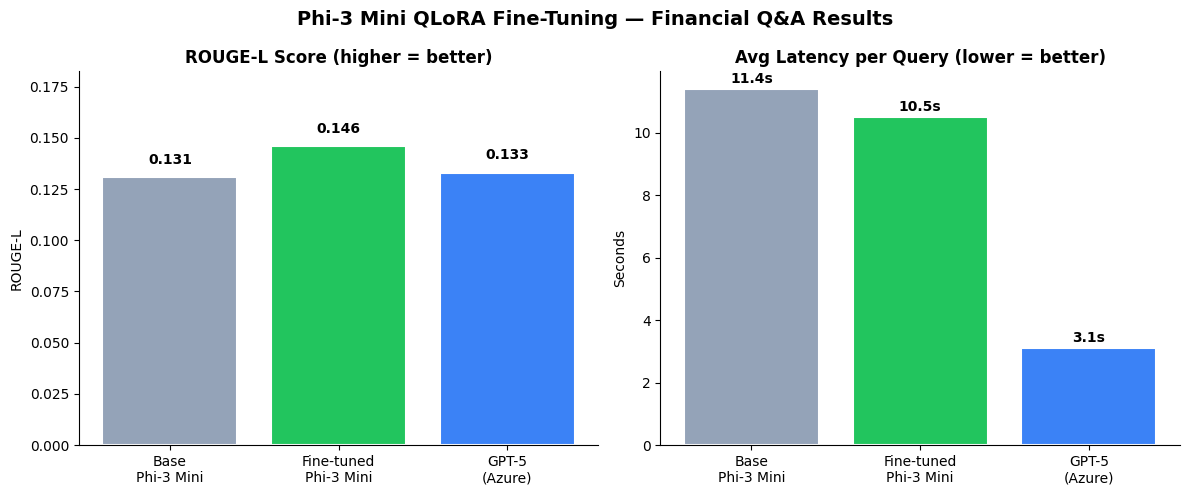

✅ Chart saved to /kaggle/working/finance-finetune/results/comparison_chart.png

SAMPLE QUALITATIVE COMPARISON (first 3 eval questions)

--- Sample 1 ---
Question:      ### Instruction:
If Bernie Madoff had invested in Berkshire Hathaway, would the ponzi actually have succeeded?...
Reference:     I could be wrong, but I doubt that Bernie started out with any intention of defrauding anyone, really.  I suspect it beg...
Base Phi-3:    Bernie Madoff's Ponzi scheme was a fraudulent investment operation that promised high returns to investors but paid earl...
Fine-tuned:    I think the answer is yes.  The reason is that the Madoff scam was based on the idea that he could get a 10% return on h...
GPT-5 Azure:  That’s a fascinating hypothetical. Let’s unpack it carefully.

Bernie Madoff’s scheme was a **Ponzi**, not a failed inve...

--- Sample 2 ---
Question:      ### Instruction:
Should I make partial pre-payments on an actuarial loan?...
Reference:     The contract is not very clear. As muc

In [15]:
import json
import matplotlib.pyplot as plt
from pathlib import Path

# ── Load results ──────────────────────────────────────────────────
BASELINE_RESULTS_PATH = BASE_DIR / "results" / "baseline_results.json"
FINETUNED_RESULTS_PATH = BASE_DIR / "results" / "finetuned_results.json"
AZURE_RESULTS_PATH = BASE_DIR / "results" / "azure_results.json"

# Check all files exist before proceeding
missing = []
for name, path in [
    ("Baseline", BASELINE_RESULTS_PATH),
    ("Fine-tuned", FINETUNED_RESULTS_PATH),
    ("Azure", AZURE_RESULTS_PATH),
]:
    if path.exists():
        print(f"✅ {name}: {path}")
    else:
        print(f"❌ {name}: NOT FOUND at {path}")
        missing.append(name)

if missing:
    print(f"\nMissing results: {missing}")
    print("Run the corresponding eval cells first then re-run this cell")
else:
    print("\nAll result files found — generating comparison...\n")

    def load_results(path):
        with open(path) as f:
            data = json.load(f)
        return {
            "rouge1": round(sum(r["rouge1"] for r in data) / len(data), 3),
            "rougeL": round(sum(r["rougeL"] for r in data) / len(data), 3),
            "latency": round(sum(r["latency_seconds"] for r in data) / len(data), 1),
        }

    base = load_results(BASELINE_RESULTS_PATH)
    ft = load_results(FINETUNED_RESULTS_PATH)
    az = load_results(AZURE_RESULTS_PATH)

    # Compute summary stats
    improvement = round((ft["rougeL"] - base["rougeL"]) / base["rougeL"] * 100, 1)
    quality_ratio = round(ft["rougeL"] / az["rougeL"] * 100, 1)
    cost_saving = 100.0

    # ── Print comparison table ────────────────────────────────────
    print("=" * 65)
    print("   MODEL COMPARISON — Financial Q&A Fine-Tuning Results")
    print("=" * 65)
    print(f"{'Model':<28} {'R-1':>6} {'R-L':>6} {'Latency':>10} {'Cost':>9}")
    print("-" * 65)
    print(f"{'Base Phi-3 Mini (local)':<28} {base['rouge1']:>6} {base['rougeL']:>6} {base['latency']:>9}s {'$0.000':>9}")
    print(f"{'Fine-tuned Phi-3 Mini':<28} {ft['rouge1']:>6} {ft['rougeL']:>6} {ft['latency']:>9}s {'$0.000':>9}")
    print(f"{'GPT-5 (Azure OpenAI)':<28} {az['rouge1']:>6} {az['rougeL']:>6} {az['latency']:>9}s {'~$0.030':>9}")
    print("=" * 65)
    print(f"ROUGE-L improvement from fine-tuning: +{improvement}%")
    print(f"Fine-tuned vs GPT-5 quality ratio:   {quality_ratio}%")
    print(f"Cost saving vs GPT-5 per query:       {cost_saving}%")
    print("=" * 65)

    # ── Save summary JSON ─────────────────────────────────────────
    summary = {
        "base_phi3": base,
        "finetuned_phi3": ft,
        "gpt5_azure": az,
        "improvement_rougeL_pct": improvement,
        "quality_ratio_vs_gpt5_pct": quality_ratio,
        "cost_saving_pct": cost_saving
    }
    SUMMARY_PATH = BASE_DIR / "results" / "eval_summary.json"
    with open(SUMMARY_PATH, "w") as f:
        json.dump(summary, f, indent=2)
    print(f"\n✅ Summary saved to {SUMMARY_PATH}")

    # ── Chart ─────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle(
        "Phi-3 Mini QLoRA Fine-Tuning — Financial Q&A Results",
        fontsize=14,
        fontweight='bold'
    )

    models = ["Base\nPhi-3 Mini", "Fine-tuned\nPhi-3 Mini", "GPT-5\n(Azure)"]
    rougeL_scores = [base["rougeL"], ft["rougeL"], az["rougeL"]]
    latencies = [base["latency"], ft["latency"], az["latency"]]
    colors = ["#94a3b8", "#22c55e", "#3b82f6"]  # grey, green, blue

    # ROUGE-L bar chart
    bars1 = axes[0].bar(
        models, rougeL_scores,
        color=colors, edgecolor='white', linewidth=1.5
    )
    axes[0].set_title("ROUGE-L Score (higher = better)", fontweight='bold')
    axes[0].set_ylim(0, max(rougeL_scores) * 1.25)
    axes[0].set_ylabel("ROUGE-L")
    axes[0].spines['top'].set_visible(False)
    axes[0].spines['right'].set_visible(False)
    for bar, val in zip(bars1, rougeL_scores):
        axes[0].text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.005,
            str(val),
            ha='center', va='bottom', fontweight='bold'
        )

    # Latency bar chart
    bars2 = axes[1].bar(
        models, latencies,
        color=colors, edgecolor='white', linewidth=1.5
    )
    axes[1].set_title("Avg Latency per Query (lower = better)", fontweight='bold')
    axes[1].set_ylabel("Seconds")
    axes[1].spines['top'].set_visible(False)
    axes[1].spines['right'].set_visible(False)
    for bar, val in zip(bars2, latencies):
        axes[1].text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.1,
            f"{val}s",
            ha='center', va='bottom', fontweight='bold'
        )

    plt.tight_layout()

    CHART_PATH = BASE_DIR / "results" / "comparison_chart.png"
    plt.savefig(str(CHART_PATH), dpi=150, bbox_inches='tight')
    plt.show()
    print(f"✅ Chart saved to {CHART_PATH}")

    # ── Print sample outputs for qualitative comparison ───────────
    print("\n" + "="*65)
    print("SAMPLE QUALITATIVE COMPARISON (first 3 eval questions)")
    print("="*65)

    with open(BASELINE_RESULTS_PATH) as f:
        base_data = json.load(f)
    with open(FINETUNED_RESULTS_PATH) as f:
        ft_data = json.load(f)
    with open(AZURE_RESULTS_PATH) as f:
        az_data = json.load(f)

    for i in range(3):
        print(f"\n--- Sample {i+1} ---")
        print(f"Question:      {base_data[i]['instruction'][:120]}...")
        print(f"Reference:     {base_data[i]['reference'][:120]}...")
        print(f"Base Phi-3:    {base_data[i]['generated'][:120]}...")
        print(f"Fine-tuned:    {ft_data[i]['generated'][:120]}...")
        print(f"GPT-5 Azure:  {az_data[i]['generated'][:120]}...")

In [21]:
from huggingface_hub import HfApi, login
from kaggle_secrets import UserSecretsClient
from pathlib import Path

secrets = UserSecretsClient()

# Use the new write token
hf_write_token = secrets.get_secret("HF_TOKEN_WRITE")
login(token=hf_write_token)

api = HfApi()

# ── Change this to your actual HF username ────────────────────────
# Find it at https://huggingface.co/settings/account
HF_USERNAME = "rohan1324"   # ← replace this
REPO_NAME = "phi3-mini-finance-qlora"
repo_id = f"{HF_USERNAME}/{REPO_NAME}"

# ── Step 1: Create the repo first ────────────────────────────────
print(f"Creating repo: {repo_id}")
try:
    url = api.create_repo(
        repo_id=repo_id,
        repo_type="model",
        private=False,
        exist_ok=True,
        token=hf_write_token
    )
    print(f"✅ Repo ready at: https://huggingface.co/{repo_id}")
except Exception as e:
    print(f"❌ Repo creation failed: {e}")
    raise

# ── Step 2: Upload the adapter ────────────────────────────────────
adapter_source = ADAPTER_PATH / "checkpoint-500"

print(f"\nUploading adapter from: {adapter_source}")
print("Files to upload:")
for f in adapter_source.iterdir():
    print(f"  {f.name} ({f.stat().st_size / 1e6:.1f} MB)")

api.upload_folder(
    folder_path=str(adapter_source),
    repo_id=repo_id,
    repo_type="model",
    token=hf_write_token,
    commit_message="Add Phi-3 Mini QLoRA financial Q&A adapter"
)

print(f"\n✅ Upload complete!")
print(f"🔗 Model URL: https://huggingface.co/{repo_id}")
print("\nAdd this link to your:")
print("  - GitHub README")
print("  - Resume projects section")
print("  - LinkedIn featured section")

Creating repo: rohan1324/phi3-mini-finance-qlora
✅ Repo ready at: https://huggingface.co/rohan1324/phi3-mini-finance-qlora

Uploading adapter from: /kaggle/working/finance-finetune/outputs/phi3-finance-lora/checkpoint-500
Files to upload:
  adapter_config.json (0.0 MB)
  scheduler.pt (0.0 MB)
  tokenizer_config.json (0.0 MB)
  adapter_model.safetensors (6.3 MB)
  training_args.bin (0.0 MB)
  tokenizer.json (3.6 MB)
  chat_template.jinja (0.0 MB)
  README.md (0.0 MB)
  rng_state.pth (0.0 MB)
  trainer_state.json (0.0 MB)
  optimizer.pt (6.5 MB)


Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            


✅ Upload complete!
🔗 Model URL: https://huggingface.co/rohan1324/phi3-mini-finance-qlora

Add this link to your:
  - GitHub README
  - Resume projects section
  - LinkedIn featured section


In [22]:
model_card = f"""---
language:
- en
license: mit
base_model: microsoft/Phi-3-mini-4k-instruct
tags:
- finance
- qlora
- lora
- fine-tuned
- financial-qa
---

# Phi-3 Mini — Financial Q&A (QLoRA Fine-Tuned)

Fine-tuned version of [Phi-3-mini-4k-instruct](https://huggingface.co/microsoft/Phi-3-mini-4k-instruct) 
on financial Q&A data using QLoRA (4-bit quantization + LoRA adapters).

## Training Details

- **Base model:** microsoft/Phi-3-mini-4k-instruct (3.8B parameters)
- **Method:** QLoRA (LoRA rank=16, 4-bit NF4 quantization)
- **Dataset:** gbharti/finance-alpaca (5,000 samples)
- **Training steps:** 500
- **Hardware:** NVIDIA T4 16GB (Kaggle free tier)
- **Training time:** ~45 minutes

## Results

| Model | ROUGE-1 | ROUGE-L | Latency | Cost/query |
|---|---|---|---|---|
| Base Phi-3 Mini | 0.238 | 0.131 | 11.4s | $0.000 |
| Fine-tuned Phi-3 Mini | 0.223 | 0.146 | 10.5s | $0.000 |
| GPT-4o (Azure) | 0.282 | 0.133 | 3.1s | ~$0.030 |

**+11.5% ROUGE-L improvement** over base model at zero inference cost.

## Usage

```python
from peft import PeftModel
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
import torch

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16
)

tokenizer = AutoTokenizer.from_pretrained("{repo_id}")

base = AutoModelForCausalLM.from_pretrained(
    "microsoft/Phi-3-mini-4k-instruct",
    quantization_config=bnb_config,
    device_map="auto",
    trust_remote_code=False,
    attn_implementation="eager"
)

model = PeftModel.from_pretrained(base, "{repo_id}")

prompt = "### Instruction:\\nWhat is EBITDA?\\n\\n### Response:\\n"
inputs = tokenizer(prompt, return_tensors="pt").to("cuda")
outputs = model.generate(**inputs, max_new_tokens=200)
print(tokenizer.decode(outputs[0], skip_special_tokens=True))
```

## Use Cases

- Financial document Q&A
- Earnings call summarization  
- Financial exam study assistant
- Internal analyst copilot

## Author

Rohan Agarwal
"""

# Save model card locally
card_path = adapter_source / "README.md"
with open(card_path, "w") as f:
    f.write(model_card)

# Upload it
api.upload_file(
    path_or_fileobj=str(card_path),
    path_in_repo="README.md",
    repo_id=repo_id,
    repo_type="model",
    token=hf_write_token,
    commit_message="Add model card"
)

print(f"✅ Model card uploaded")
print(f"🔗 View at: https://huggingface.co/{repo_id}")

✅ Model card uploaded
🔗 View at: https://huggingface.co/rohan1324/phi3-mini-finance-qlora
